# Hourly Delay Profile

Shows the local hours when buses are most late.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "hourly_delay_profile",
    PROJECT_ROOT / "analysis" / "hourly-delay-profile.py",
)
hourly = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hourly)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
LINE_REF = None
MIN_OBSERVATIONS = 30
LIMIT = 24
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    line_ref = LINE_REF
    min_observations = MIN_OBSERVATIONS
    limit = LIMIT
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

df = hourly.load_observations(Args)
profile = hourly.build_profile(Args, df)
profile

,hour_local,bucket_count,raw_poll_count,signed_mean_delay_min,median_delay_min,p75_delay_min,p90_delay_min,p95_delay_min,pct_over_3_min_late,pct_over_5_min_late,pct_early,pct_over_1_min_early,pct_over_3_min_early
0,15:00,34744,92428,0.92,0.47,2.13,4.57,6.47,17.54,8.54,37.25,18.99,5.83
1,16:00,33100,85454,0.75,0.32,1.89,4.12,5.68,15.70,6.67,39.87,20.42,5.38
2,14:00,32968,88716,0.61,0.25,1.70,3.68,5.48,13.38,5.90,40.48,21.10,5.61
3,13:00,25866,68328,0.55,0.32,1.65,3.35,4.83,12.06,4.65,38.83,19.50,5.97
4,12:00,20455,54413,0.30,0.08,1.32,2.93,4.23,9.62,3.35,44.52,22.23,5.93
5,17:00,30891,80225,-0.02,-0.02,1.05,2.62,4.00,8.10,3.16,50.22,28.27,8.93
6,18:00,27665,71074,0.01,0.00,1.07,2.62,3.92,7.98,2.82,48.38,26.69,8.74
7,11:00,18705,49924,-0.15,0.00,1.05,2.50,3.82,7.31,2.75,47.48,24.77,8.02
8,19:00,23809,59970,0.07,0.07,1.12,2.48,3.61,7.17,1.92,44.87,23.05,6.59
9,20:00,21237,54634,0.12,0.00,1.02,2.37,3.65,6.85,2.87,47.47,23.82,6.04


Delay has positive and negative values. Positive values mean that bus is is late. Negative value means bus is early.

Text(0, 0.5, 'P90 delay, minutes')

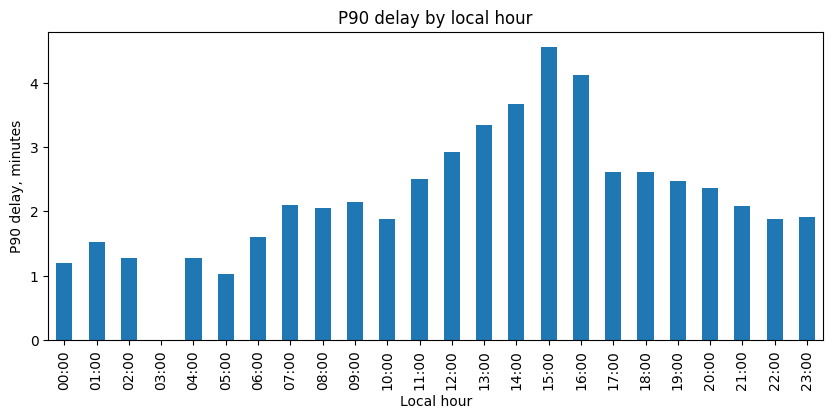

In [3]:
ax = profile.sort_values("hour_local").plot.bar(
    x="hour_local",
    y="p90_delay_min",
    legend=False,
    figsize=(10, 4),
    title="P90 delay by local hour",
)
ax.set_xlabel("Local hour")
ax.set_ylabel("P90 delay, minutes")